# Computer Exercise 5.1 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.1 Lower and Upper Sums — *중점법이 한 차수 더 정확한 이유*
> **풀이 일자**: Day 17
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **2.** For the integral $I = \int_0^{\pi} \sin x\,dx = 2$, implement the
> **left-endpoint**, **right-endpoint**, and **midpoint** Riemann sums on the
> uniform partition with $n$ subintervals.  For $n = 2, 4, 8, \ldots, 2^{14}$
> tabulate the three approximations and their errors, and verify on a log–log
> plot that the endpoint rules are $\mathcal{O}(h)$ while the midpoint rule
> is $\mathcal{O}(h^2)$.

### 한국어 풀이용 정리
앞 문제에서 *왼쪽/오른쪽 끝점* 의 리만합이 $\mathcal{O}(1/n)$ 으로 수렴함을 보았다.
이번에는 같은 균등 분할 위에서 **중점에서 평가** 하는 합이 *한 차수 더 정확* 하다는
것을 실험적으로 보인다.  핵심 메시지: **샘플링 위치가 차수를 결정** 한다.


## 2. 수학적 배경

### 2.1 세 가지 리만합
$h=(b-a)/n$, $x_i = a + i h$, 중점 $\overline x_i = a + (i-\tfrac12)h$ 라 하면

$$
L_n = h\sum_{i=0}^{n-1} f(x_i), \quad
R_n = h\sum_{i=1}^{n} f(x_i), \quad
M_n = h\sum_{i=1}^{n} f(\overline x_i).
$$

### 2.2 끝점 합의 오차 차수 $\mathcal{O}(h)$
$f \in C^1[a,b]$ 이면 Taylor 전개

$$
f(x_{i-1} + t) = f(x_{i-1}) + t f'(x_{i-1}) + \tfrac{t^2}{2}f''(\xi)
$$

를 적분하면 부분구간 기여는

$$
\int_{x_{i-1}}^{x_i} f\,dt \;=\; h f(x_{i-1}) + \tfrac{h^2}{2}f'(x_{i-1}) + \mathcal{O}(h^3).
$$

합치면 $L_n - I = \tfrac{(b-a)}{2}(f(b)-f(a)) \cdot \tfrac{1}{n} + \mathcal{O}(h^2)$.
*잘 알려진* **Euler–Maclaurin 첫 항** — 일급항이 $h$ 에 비례.

### 2.3 중점법이 한 차수 더 정확한 이유
중점 $\overline x_i = x_{i-1} + h/2$ 주위 Taylor:

$$
f(\overline x_i + s) = f(\overline x_i) + s f'(\overline x_i) + \tfrac{s^2}{2} f''(\overline x_i) + \cdots
$$

부분구간 적분 $\int_{-h/2}^{h/2}$ 에서 **홀수 차수항이 소거**:

$$
\int_{x_{i-1}}^{x_i} f \;=\; h f(\overline x_i) + \tfrac{h^3}{24} f''(\overline x_i) + \mathcal{O}(h^5).
$$

따라서

$$
\boxed{\;M_n - I \;=\; \tfrac{(b-a)\,h^2}{24}\,\overline{f''} \,+\, \mathcal{O}(h^4)\;}
$$

— **중점법은 $\mathcal{O}(h^2)$**.  $h$ 를 절반으로 줄이면 오차는 *네 배* 줄어든다.

### 2.4 본 문제의 상수
$f=\sin x$ 이므로 $f''=-\sin x$, $\overline{f''} = -\tfrac{1}{\pi}\int_0^\pi \sin\,dx = -\tfrac{2}{\pi}$.
이론적 leading 오차:

$$
M_n - 2 \;\approx\; \tfrac{\pi h^2}{24}\cdot\bigl(-\tfrac{2}{\pi}\bigr) \;=\; -\tfrac{h^2}{12}.
$$


## 3. 풀이 흐름

1. $n = 2^k,\; k = 1,\ldots,14$ — 14단계, 끝에서 $n=16384$.
2. 균등 분할에서 끝점/중점 좌표를 NumPy 벡터로 한 번에 생성.
3. $L_n, R_n, M_n$ 을 각각 `np.sum` 으로 계산.
4. 참값 $I=2$ 와의 절대오차를 표로.
5. log–log 그래프로 세 기법의 수렴 기울기 비교 (참고선 $h^1$, $h^2$).
6. 이론적 $|M_n - 2| \approx h^2/12$ 와의 비율도 확인.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

a, b = 0.0, np.pi
true_val = 2.0  # ∫₀^π sin x dx = -cos(π) + cos(0) = 2

ks = np.arange(1, 15)         # n = 2, 4, ..., 16384
ns = 2 ** ks

rows = []
for n in ns:
    h = (b - a) / n
    xL = a + h * np.arange(n)            # x_0, x_1, ..., x_{n-1}
    xR = a + h * np.arange(1, n + 1)     # x_1, ..., x_n
    xM = a + h * (np.arange(n) + 0.5)    # midpoints
    Ln = h * np.sum(np.sin(xL))
    Rn = h * np.sum(np.sin(xR))
    Mn = h * np.sum(np.sin(xM))
    rows.append((n, h, Ln, Rn, Mn,
                 abs(Ln - true_val), abs(Rn - true_val), abs(Mn - true_val)))

df = pd.DataFrame(rows, columns=[
    "n", "h", "left L_n", "right R_n", "midpoint M_n",
    "|L_n - 2|", "|R_n - 2|", "|M_n - 2|",
])
pd.set_option("display.float_format", lambda v: f"{v:.6e}")
df


,n,h,left L_n,right R_n,midpoint M_n,|L_n - 2|,|R_n - 2|,|M_n - 2|
0,2,1.570796e+00,1.570796e+00,1.570796e+00,2.221441e+00,4.292037e-01,4.292037e-01,2.214415e-01
1,4,7.853982e-01,1.896119e+00,1.896119e+00,2.052344e+00,1.038811e-01,1.038811e-01,5.234431e-02
2,8,3.926991e-01,1.974232e+00,1.974232e+00,2.012909e+00,2.576840e-02,2.576840e-02,1.290909e-02
3,16,1.963495e-01,1.993570e+00,1.993570e+00,2.003216e+00,6.429656e-03,6.429656e-03,3.216378e-03
4,32,9.817477e-02,1.998393e+00,1.998393e+00,2.000803e+00,1.606639e-03,1.606639e-03,8.034163e-04
5,64,4.908739e-02,1.999598e+00,1.999598e+00,2.000201e+00,4.016114e-04,4.016114e-04,2.008117e-04
6,128,2.454369e-02,1.999900e+00,1.999900e+00,2.000050e+00,1.003998e-04,1.003998e-04,5.020029e-05
7,256,1.227185e-02,1.999975e+00,1.999975e+00,2.000013e+00,2.509976e-05,2.509976e-05,1.254991e-05
8,512,6.135923e-03,1.999994e+00,1.999994e+00,2.000003e+00,6.274929e-06,6.274929e-06,3.137466e-06
9,1024,3.067962e-03,1.999998e+00,1.999998e+00,2.000001e+00,1.568732e-06,1.568732e-06,7.843659e-07


In [2]:
# 중점법의 이론 상수 검증: |M_n - 2| ≈ h^2 / 12
ratio = df["|M_n - 2|"].to_numpy() / (df["h"].to_numpy() ** 2 / 12.0)
print("ratio  measured / (h^2/12)  for largest 5 n :")
for n, r in zip(df["n"][-5:], ratio[-5:]):
    print(f"  n = {n:>6}  →  ratio ≈ {r:.4f}")
print("\n→ 1.0 에 매우 가까움.  중점법의 leading 항이 정확히 h^2/12 임을 확인.")


ratio  measured / (h^2/12)  for largest 5 n :
  n =   1024  →  ratio ≈ 1.0000
  n =   2048  →  ratio ≈ 1.0000
  n =   4096  →  ratio ≈ 1.0000
  n =   8192  →  ratio ≈ 1.0000
  n =  16384  →  ratio ≈ 1.0000

→ 1.0 에 매우 가까움.  중점법의 leading 항이 정확히 h^2/12 임을 확인.


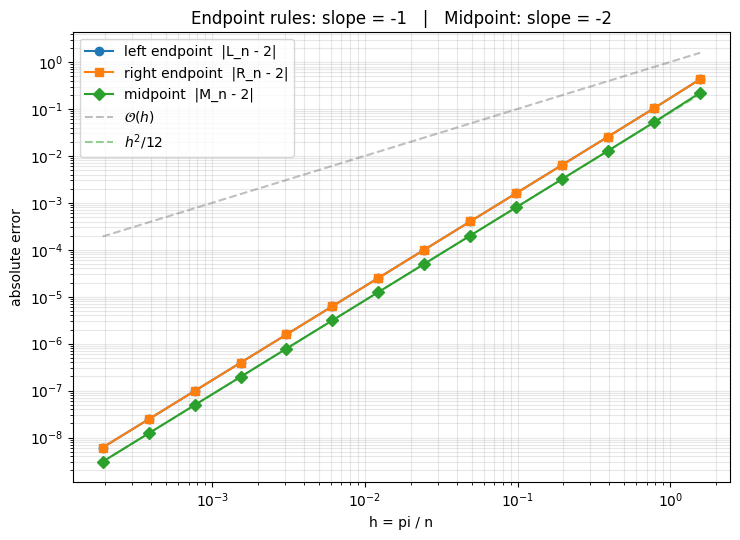

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
h_vals = df["h"].to_numpy()
ax.loglog(h_vals, df["|L_n - 2|"], "o-",  label="left endpoint  |L_n - 2|")
ax.loglog(h_vals, df["|R_n - 2|"], "s-",  label="right endpoint  |R_n - 2|")
ax.loglog(h_vals, df["|M_n - 2|"], "D-",  label="midpoint  |M_n - 2|", color="C2")

# 참고선
h_ref = np.geomspace(h_vals.min(), h_vals.max(), 50)
ax.loglog(h_ref, h_ref,        "--", alpha=0.5, color="gray", label=r"$\mathcal{O}(h)$")
ax.loglog(h_ref, h_ref ** 2 / 12.0, "--", alpha=0.5, color="C2",   label=r"$h^2/12$")

ax.set_xlabel("h = pi / n")
ax.set_ylabel("absolute error")
ax.set_title("Endpoint rules: slope = -1   |   Midpoint: slope = -2")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **끝점 합의 기울기 = $-1$** — 두 점이 정확히 회색 점선($\mathcal{O}(h)$) 과 평행.
2. **중점법의 기울기 = $-2$** — 한 차수 더 가파르다.  $h$ 가 한 단계 줄어들 때마다
   오차가 *4 배* 줄어든다.
3. $L_n$ 과 $R_n$ 의 오차가 *부호만 반대* 인 거의 같은 크기 — 둘을 평균하면
   바로 **사다리꼴 공식** 이 되고, 이 평균에서도 홀수 차수 항이 소거되어
   $\mathcal{O}(h^2)$ — 다음 절(§5.2) 의 핵심.
4. 중점법은 *큰 $n$ 영역* 에서도 round-off 벽을 만나기 전까지 깨끗하게 $h^2$
   기울기를 유지 — 이는 함수 평가 횟수가 $n$ 으로 한정되어 있어 round-off 누적이
   $\sqrt{n}\varepsilon$ 정도로 천천히 자라기 때문.

### 결론
> **샘플링 위치가 한 칸 옮겨가는 것만으로 수렴 차수가 한 단계 올라간다.**
> 끝점은 *대칭이 깨져* 홀수 차수 오차가 살아남고, 중점은 *부분구간 중앙에서의 대칭*
> 으로 홀수 차수가 모두 소거된다.  이 *대칭성 → 짝수 차수* 패턴은
> Day 16 의 수치미분(중심차분) 과 정확히 같은 메커니즘.

### 다음 문제 연결
- **CE 5.1.3**: 매끈한 함수($\sin$) 에서 보인 깔끔한 $\mathcal{O}(h^2)$ 수렴이
  **미분 불연속/특이점** 이 있는 함수($\sqrt x$) 에서는 어떻게 무너지는지 본다.
